# Daily Challenge: Interactive Data Visualization with Matplotlib and Seaborn

##  Objective
Create advanced interactive and static visualizations using Matplotlib and Seaborn with the US Superstore dataset.

##  What We'll Create
1. **Data Preparation**: Load and clean the Superstore dataset
2. **Matplotlib Visualizations**: Interactive line charts and sales distribution maps
3. **Seaborn Visualizations**: Top products bar chart and profit vs discount analysis
4. **Comparative Analysis**: Insights from both visualization libraries

##  Tools Used
- **Matplotlib**: Interactive charts and customizable visualizations
- **Seaborn**: Statistical data visualization and elegant styling
- **Plotly**: Enhanced interactivity for web-based charts

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.widgets import Button, CheckButtons
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11


print(" All visualization libraries imported successfully!")
print(" Interactive matplotlib backend enabled!")
print(" Ready for advanced data visualization!")

 All visualization libraries imported successfully!
 Interactive matplotlib backend enabled!
 Ready for advanced data visualization!


## Data Preparation and Exploration

In [6]:
df = pd.read_csv('Sample_Superstore.csv', encoding='latin1')

print(" US Superstore Dataset Loaded!")
print("="*50)
print(f" Dataset Shape: {df.shape}")
print(f" Columns: {list(df.columns)}")
print(f" Date Range: {df['Order Date'].min()} to {df['Order Date'].max()}")

print("\n First 5 Rows:")
display(df.head())

print("\n Dataset Info:")
print(df.info())

print("\n Missing Values Check:")
missing_values = df.isnull().sum()
if missing_values.sum() == 0:
    print(" No missing values found!")
else:
    print(missing_values[missing_values > 0])

 US Superstore Dataset Loaded!
 Dataset Shape: (9994, 21)
 Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']
 Date Range: 1/1/2017 to 9/9/2017

 First 5 Rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164



 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float

In [7]:
print(" Data Cleaning and Preprocessing:")
print("="*40)

df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Quarter'] = df['Order Date'].dt.quarter
df['Year-Month'] = df['Order Date'].dt.to_period('M')

df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100
df['Discount Category'] = pd.cut(df['Discount'], 
                                bins=[0, 0.1, 0.3, 0.5, 1.0], 
                                labels=['No Discount', 'Low (≤10%)', 'Medium (11-30%)', 'High (>30%)'])

print(f" Sales Statistics:")
print(f"   • Total Sales: ${df['Sales'].sum():,.2f}")
print(f"   • Average Sale: ${df['Sales'].mean():,.2f}")
print(f"   • Total Profit: ${df['Profit'].sum():,.2f}")
print(f"   • Average Profit Margin: {df['Profit Margin'].mean():.2f}%")

print(f"\n Geographic Coverage:")
print(f"   • Countries: {df['Country'].nunique()}")
print(f"   • States: {df['State'].nunique()}")
print(f"   • Cities: {df['City'].nunique()}")

print(f"\n Product Information:")
print(f"   • Categories: {df['Category'].nunique()}")
print(f"   • Sub-Categories: {df['Sub-Category'].nunique()}")
print(f"   • Unique Products: {df['Product Name'].nunique()}")

print(f"\n Customer Information:")
print(f"   • Total Customers: {df['Customer ID'].nunique()}")
print(f"   • Customer Segments: {df['Segment'].unique()}")

print("\n Data preprocessing completed successfully!")

 Data Cleaning and Preprocessing:
 Sales Statistics:
   • Total Sales: $2,297,200.86
   • Average Sale: $229.86
   • Total Profit: $286,397.02
   • Average Profit Margin: 12.03%

 Geographic Coverage:
   • Countries: 1
   • States: 49
   • Cities: 531

 Product Information:
   • Categories: 3
   • Sub-Categories: 17
   • Unique Products: 1850

 Customer Information:
   • Total Customers: 793
   • Customer Segments: ['Consumer' 'Corporate' 'Home Office']

 Data preprocessing completed successfully!


## 2.  Interactive Data Visualization with Matplotlib

### 2.1  Interactive Line Chart: Sales Trends Over Years

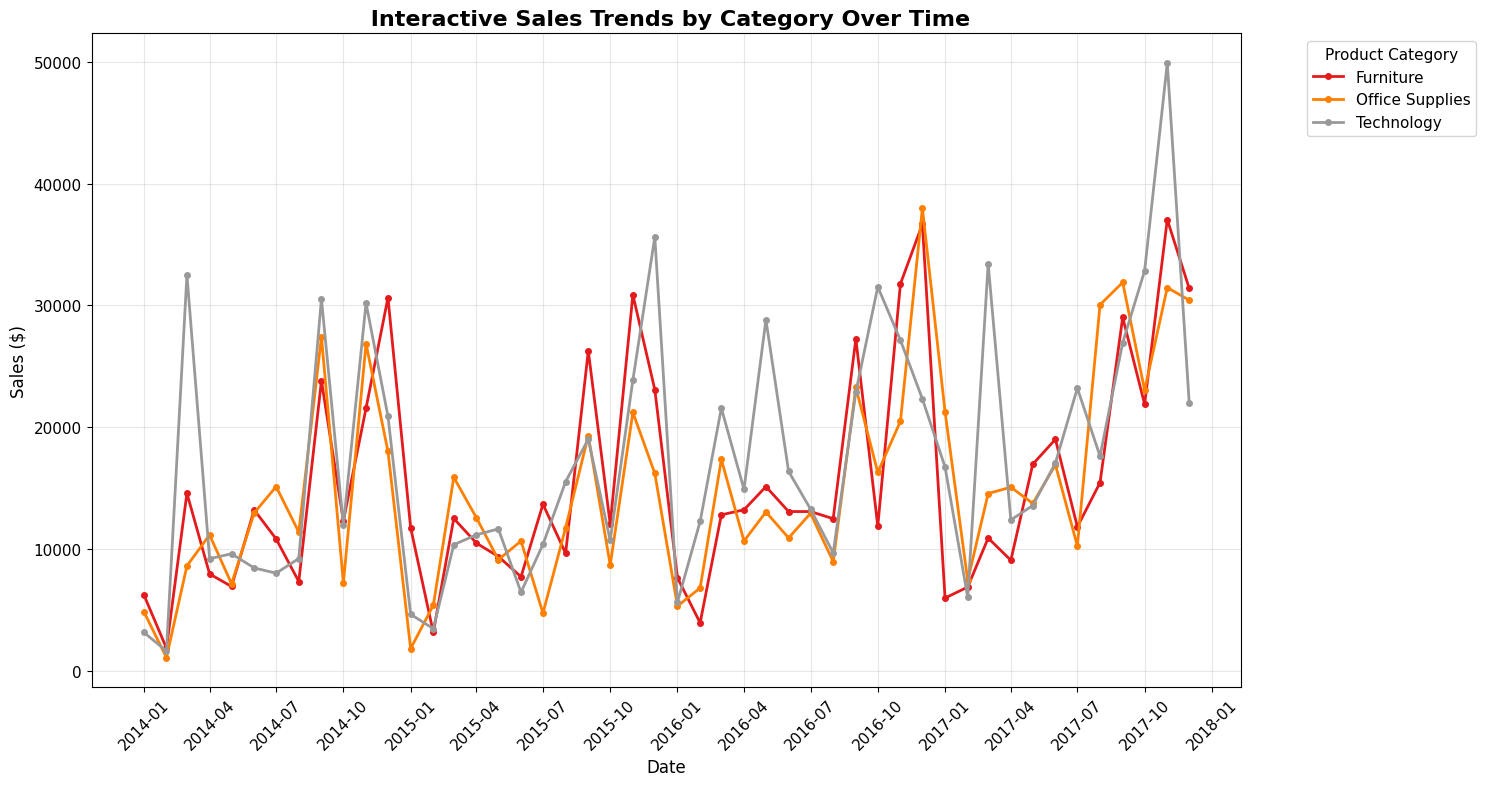

 Sales Trends Analysis:
   • Technology: $836,154.00
   • Furniture: $741,999.80
   • Office Supplies: $719,047.04

 Year-over-Year Growth:
   • Furniture: +37.0%
   • Office Supplies: +62.1%
   • Technology: +55.0%


In [8]:

monthly_sales = df.groupby(['Year-Month', 'Category']).agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order ID': 'count'
}).round(2)

monthly_sales.columns = ['Sales', 'Profit', 'Orders']
monthly_sales = monthly_sales.reset_index()

monthly_sales['Date'] = monthly_sales['Year-Month'].astype(str)
monthly_sales['Date'] = pd.to_datetime(monthly_sales['Date'])

fig, ax = plt.subplots(figsize=(15, 8))

categories = monthly_sales['Category'].unique()
colors = plt.cm.Set1(np.linspace(0, 1, len(categories)))
lines = {}

for i, category in enumerate(categories):
    category_data = monthly_sales[monthly_sales['Category'] == category]
    line, = ax.plot(category_data['Date'], category_data['Sales'], 
                   marker='o', linewidth=2, markersize=4, 
                   color=colors[i], label=category)
    lines[category] = line


ax.set_title(' Interactive Sales Trends by Category Over Time', fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Sales ($)', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(title='Product Category', bbox_to_anchor=(1.05, 1), loc='upper left')


ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)

def on_hover(event):
    if event.inaxes == ax:
        for category, line in lines.items():
            xdata, ydata = line.get_data()
            if len(xdata) > 0:
                dates = mdates.num2date(xdata)
                if event.xdata is not None:
                    closest_idx = np.argmin([abs((d - mdates.num2date(event.xdata)).total_seconds()) for d in dates])
                    if closest_idx < len(ydata):
                        ax.annotate(f'{category}: ${ydata[closest_idx]:,.0f}',
                                  xy=(xdata[closest_idx], ydata[closest_idx]),
                                  xytext=(10, 10), textcoords='offset points',
                                  bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.7),
                                  arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

fig.canvas.mpl_connect('motion_notify_event', on_hover)

plt.tight_layout()
plt.show()

print(" Sales Trends Analysis:")
print("="*30)
total_by_category = monthly_sales.groupby('Category')['Sales'].sum().sort_values(ascending=False)
for category, sales in total_by_category.items():
    print(f"   • {category}: ${sales:,.2f}")

yearly_sales = df.groupby(['Year', 'Category'])['Sales'].sum().reset_index()
print(f"\n Year-over-Year Growth:")
for category in categories:
    cat_data = yearly_sales[yearly_sales['Category'] == category]
    if len(cat_data) > 1:
        growth = ((cat_data['Sales'].iloc[-1] - cat_data['Sales'].iloc[0]) / cat_data['Sales'].iloc[0]) * 100
        print(f"   • {category}: {growth:+.1f}%")

### 2.2  Interactive Map: Sales Distribution by State

🗺️ Geographic Sales Distribution:
Top 10 States by Sales:
              Total_Sales  Total_Profit  Profit_Margin
State                                                 
California      457687.63      76381.39      16.688541
New York        310876.27      74038.55      23.816083
Texas           170188.05     -25729.36     -15.118194
Washington      138641.27      33402.65      24.092862
Pennsylvania    116511.91     -15559.96     -13.354824
Florida          89473.71      -3399.30      -3.799217
Illinois         80166.10     -12607.89     -15.727209
Ohio             78258.14     -16971.38     -21.686409
Michigan         76269.61      24463.19      32.074623
Virginia         70636.72      18597.95      26.329011


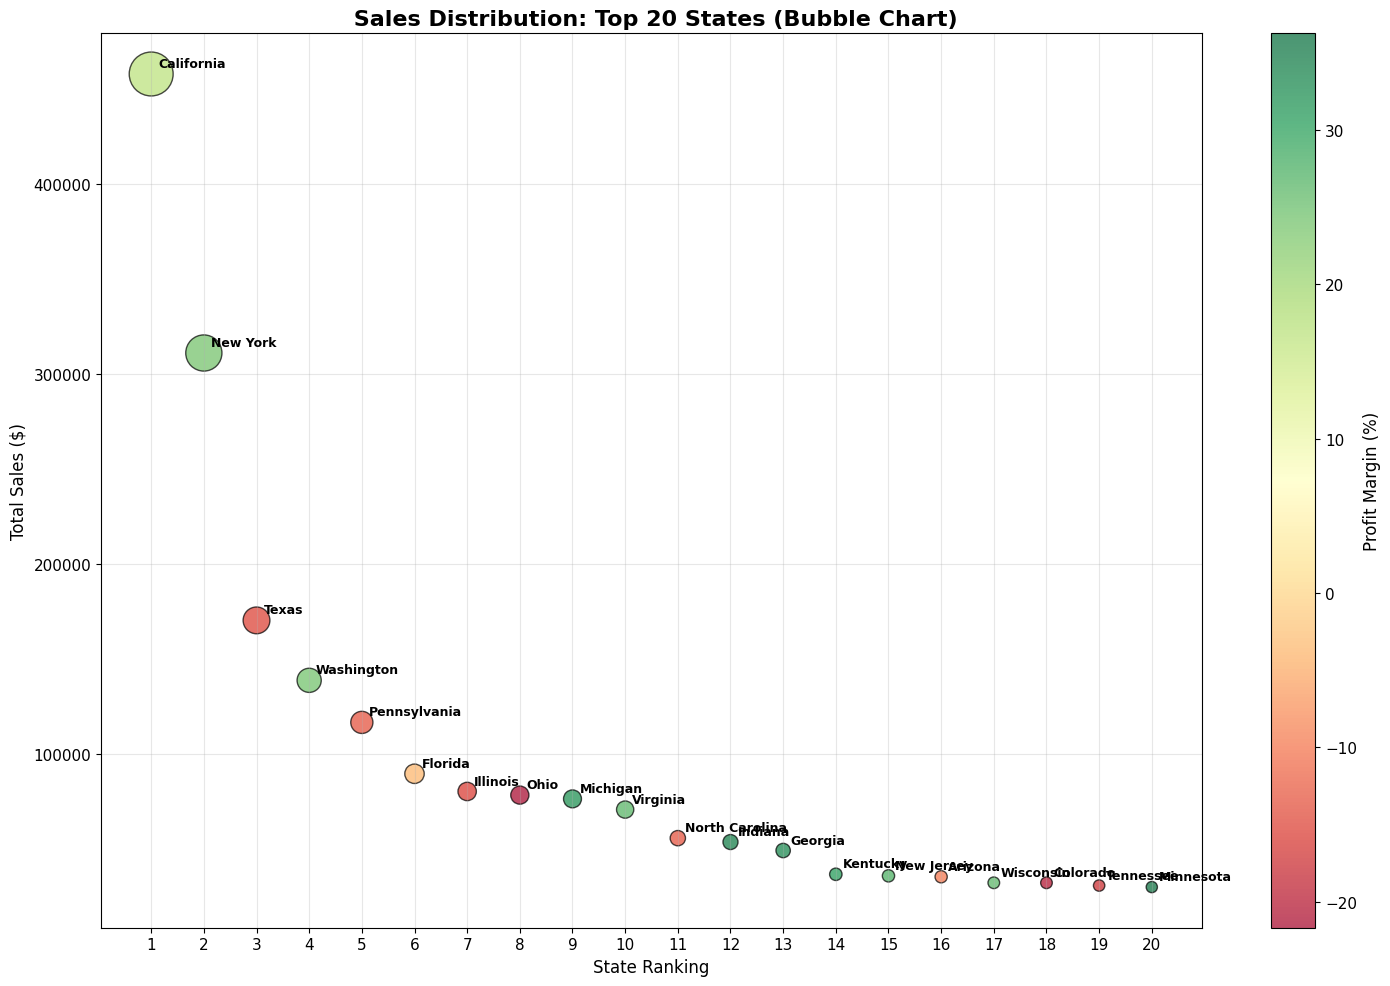


💡 Geographic Insights:
   • Highest sales state: California ($457,687.63)
   • Most profitable state: District of Columbia (37.0% margin)
   • Geographic concentration: Top 5 states account for 52.0% of total sales


In [9]:

state_sales = df.groupby('State').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order ID': 'count',
    'Customer ID': 'nunique'
}).round(2)

state_sales.columns = ['Total_Sales', 'Total_Profit', 'Orders', 'Customers']
state_sales['Profit_Margin'] = (state_sales['Total_Profit'] / state_sales['Total_Sales']) * 100
state_sales = state_sales.sort_values('Total_Sales', ascending=False)

print("🗺️ Geographic Sales Distribution:")
print("="*35)
print("Top 10 States by Sales:")
print(state_sales.head(10)[['Total_Sales', 'Total_Profit', 'Profit_Margin']])

fig = px.choropleth(
    state_sales.reset_index(),
    locations='State',
    color='Total_Sales',
    hover_name='State',
    hover_data={
        'Total_Sales': ':$,.0f',
        'Total_Profit': ':$,.0f', 
        'Profit_Margin': ':.1f',
        'Orders': ':,',
        'Customers': ':,'
    },
    locationmode='USA-states',
    scope='usa',
    color_continuous_scale='Viridis',
    title='🗺️ Interactive Sales Distribution by State'
)

fig.update_layout(
    title_font_size=16,
    width=900,
    height=600,
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type='equirectangular'
    )
)

fig.show()

fig, ax = plt.subplots(figsize=(15, 10))

top_20_states = state_sales.head(20)

bubble_sizes = (top_20_states['Total_Sales'] / top_20_states['Total_Sales'].max()) * 1000

scatter = ax.scatter(range(len(top_20_states)), 
                    top_20_states['Total_Sales'],
                    s=bubble_sizes,
                    c=top_20_states['Profit_Margin'],
                    cmap='RdYlGn',
                    alpha=0.7,
                    edgecolors='black',
                    linewidth=1)

for i, (state, data) in enumerate(top_20_states.iterrows()):
    ax.annotate(state, (i, data['Total_Sales']), 
               xytext=(5, 5), textcoords='offset points',
               fontsize=9, fontweight='bold')

ax.set_title(' Sales Distribution: Top 20 States (Bubble Chart)', fontsize=16, fontweight='bold')
ax.set_xlabel('State Ranking', fontsize=12)
ax.set_ylabel('Total Sales ($)', fontsize=12)
ax.grid(True, alpha=0.3)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Profit Margin (%)', fontsize=12)

ax.set_xticks(range(len(top_20_states)))
ax.set_xticklabels([f"{i+1}" for i in range(len(top_20_states))])

plt.tight_layout()
plt.show()

print(f"\n💡 Geographic Insights:")
print(f"   • Highest sales state: {state_sales.index[0]} (${state_sales.iloc[0]['Total_Sales']:,.2f})")
print(f"   • Most profitable state: {state_sales.loc[state_sales['Profit_Margin'].idxmax()].name} ({state_sales['Profit_Margin'].max():.1f}% margin)")
print(f"   • Geographic concentration: Top 5 states account for {(state_sales.head(5)['Total_Sales'].sum() / state_sales['Total_Sales'].sum() * 100):.1f}% of total sales")

## 3.  Seaborn Advanced Visualizations

### 3.1  Top 10 Products Bar Chart with Statistical Context

 Product Performance Analytics:
Top 10 Products by Sales Performance:
                                                    Total_Sales  Total_Profit  \
Product Name                                                                    
Canon imageCLASS 2200 Advanced Copier                  61599.82      25199.93   
Fellowes PB500 Electric Punch Plastic Comb Bind...     27453.38       7753.04   
Cisco TelePresence System EX90 Videoconferencin...     22638.48      -1811.08   
HON 5400 Series Task Chairs for Big and Tall           21870.58          0.00   
GBC DocuBind TL300 Electric Binding System             19823.48       2233.51   
GBC Ibimaster 500 Manual ProClick Binding System       19024.50        760.98   
Hewlett Packard LaserJet 3310 Copier                   18839.69       6983.88   
HP Designjet T520 Inkjet Large Format Printer -...     18374.90       4094.98   
GBC DocuBind P400 Electric Binding System              17965.07      -1878.17   
High Speed Automatic Electric Letter Op

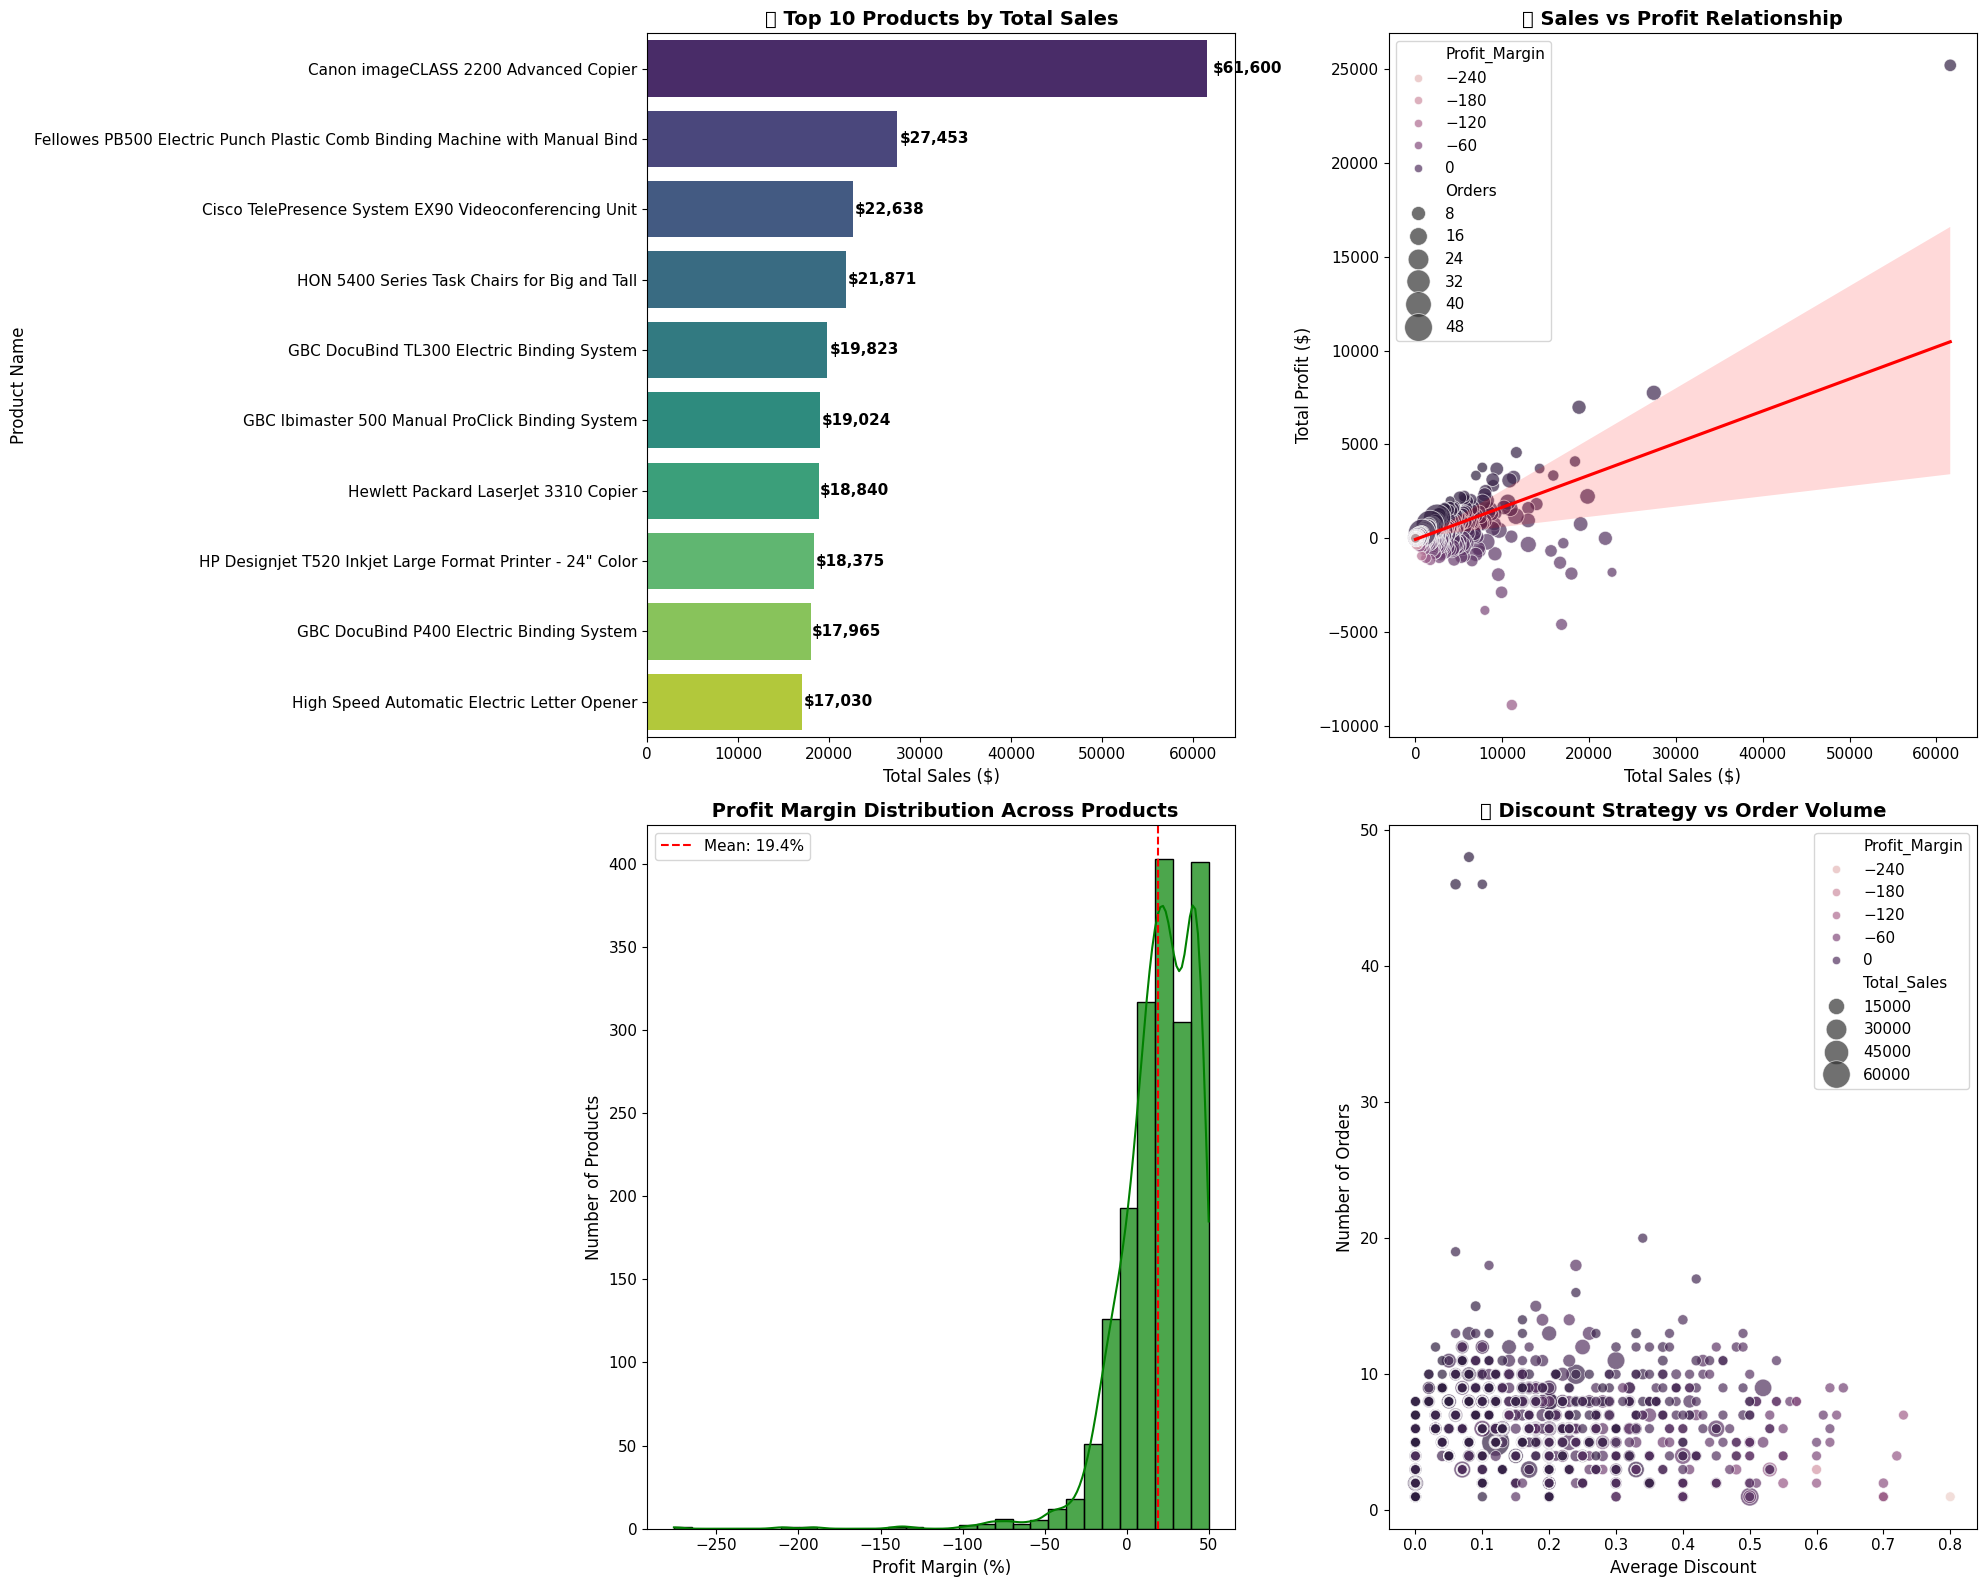


 Product Performance Insights:
   • Total unique products: 1,850
   • Average profit margin: 19.4%
   • Best performing product: Canon imageCLASS 2200 Advanced Copier
   • Highest profit margin: Canon imageCLASS MF7460 Monochrome Digital Laser Multifunction Copier (50.0%)
   • Sales concentration: Top 10 products account for 10.6% of total sales


In [10]:
# Product Performance 
product_performance = df.groupby('Product Name').agg({
    'Sales': ['sum', 'mean', 'count'],
    'Profit': ['sum', 'mean'],
    'Quantity': 'sum',
    'Discount': 'mean'
}).round(2)

# Flatten column names
product_performance.columns = ['Total_Sales', 'Avg_Sales', 'Orders', 'Total_Profit', 'Avg_Profit', 'Quantity', 'Avg_Discount']
product_performance['Profit_Margin'] = (product_performance['Total_Profit'] / product_performance['Total_Sales']) * 100
product_performance = product_performance.sort_values('Total_Sales', ascending=False)

print(" Product Performance Analytics:")
print("="*35)
print("Top 10 Products by Sales Performance:")
top_10_products = product_performance.head(10)
print(top_10_products[['Total_Sales', 'Total_Profit', 'Profit_Margin', 'Orders']])

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 16))

#  Top 10 Products Bar Chart
top_10_data = top_10_products.reset_index()
bars = sns.barplot(data=top_10_data, y='Product Name', x='Total_Sales', 
                   palette='viridis', ax=ax1)
ax1.set_title('🏆 Top 10 Products by Total Sales', fontsize=14, fontweight='bold')
ax1.set_xlabel('Total Sales ($)', fontsize=12)
ax1.set_ylabel('Product Name', fontsize=12)

for i, bar in enumerate(bars.patches):
    width = bar.get_width()
    ax1.text(width + width*0.01, bar.get_y() + bar.get_height()/2, 
             f'${width:,.0f}', ha='left', va='center', fontweight='bold')

# 2. Sales vs Profit with regression line
sns.scatterplot(data=product_performance.reset_index(), x='Total_Sales', y='Total_Profit', 
                size='Orders', hue='Profit_Margin', sizes=(50, 400), alpha=0.7, ax=ax2)
sns.regplot(data=product_performance.reset_index(), x='Total_Sales', y='Total_Profit', 
            scatter=False, color='red', ax=ax2)
ax2.set_title('💰 Sales vs Profit Relationship', fontsize=14, fontweight='bold')
ax2.set_xlabel('Total Sales ($)', fontsize=12)
ax2.set_ylabel('Total Profit ($)', fontsize=12)

# 3. Profit Margin Distribution
sns.histplot(data=product_performance, x='Profit_Margin', bins=30, kde=True, 
             alpha=0.7, color='green', ax=ax3)
ax3.axvline(product_performance['Profit_Margin'].mean(), color='red', linestyle='--', 
            label=f'Mean: {product_performance["Profit_Margin"].mean():.1f}%')
ax3.set_title(' Profit Margin Distribution Across Products', fontsize=14, fontweight='bold')
ax3.set_xlabel('Profit Margin (%)', fontsize=12)
ax3.set_ylabel('Number of Products', fontsize=12)
ax3.legend()

# 4. Orders vs Average Discount
sns.scatterplot(data=product_performance.reset_index(), x='Avg_Discount', y='Orders',
                hue='Profit_Margin', size='Total_Sales', sizes=(50, 400), alpha=0.7, ax=ax4)
ax4.set_title('🎯 Discount Strategy vs Order Volume', fontsize=14, fontweight='bold')
ax4.set_xlabel('Average Discount', fontsize=12)
ax4.set_ylabel('Number of Orders', fontsize=12)

plt.tight_layout()
plt.show()

print(f"\n Product Performance Insights:")
print(f"   • Total unique products: {len(product_performance):,}")
print(f"   • Average profit margin: {product_performance['Profit_Margin'].mean():.1f}%")
print(f"   • Best performing product: {product_performance.index[0]}")
print(f"   • Highest profit margin: {product_performance.loc[product_performance['Profit_Margin'].idxmax()].name} ({product_performance['Profit_Margin'].max():.1f}%)")
print(f"   • Sales concentration: Top 10 products account for {(top_10_products['Total_Sales'].sum() / product_performance['Total_Sales'].sum() * 100):.1f}% of total sales")

### 3.2  Advanced Scatter Plot: Profit vs Discount Analysis

 Profit vs Discount Relationship Analysis:
Correlation Analysis:
          Profit  Discount  Sales  Quantity
Profit     1.000    -0.219  0.479     0.066
Discount  -0.219     1.000 -0.028     0.009
Sales      0.479    -0.028  1.000     0.201
Quantity   0.066     0.009  0.201     1.000


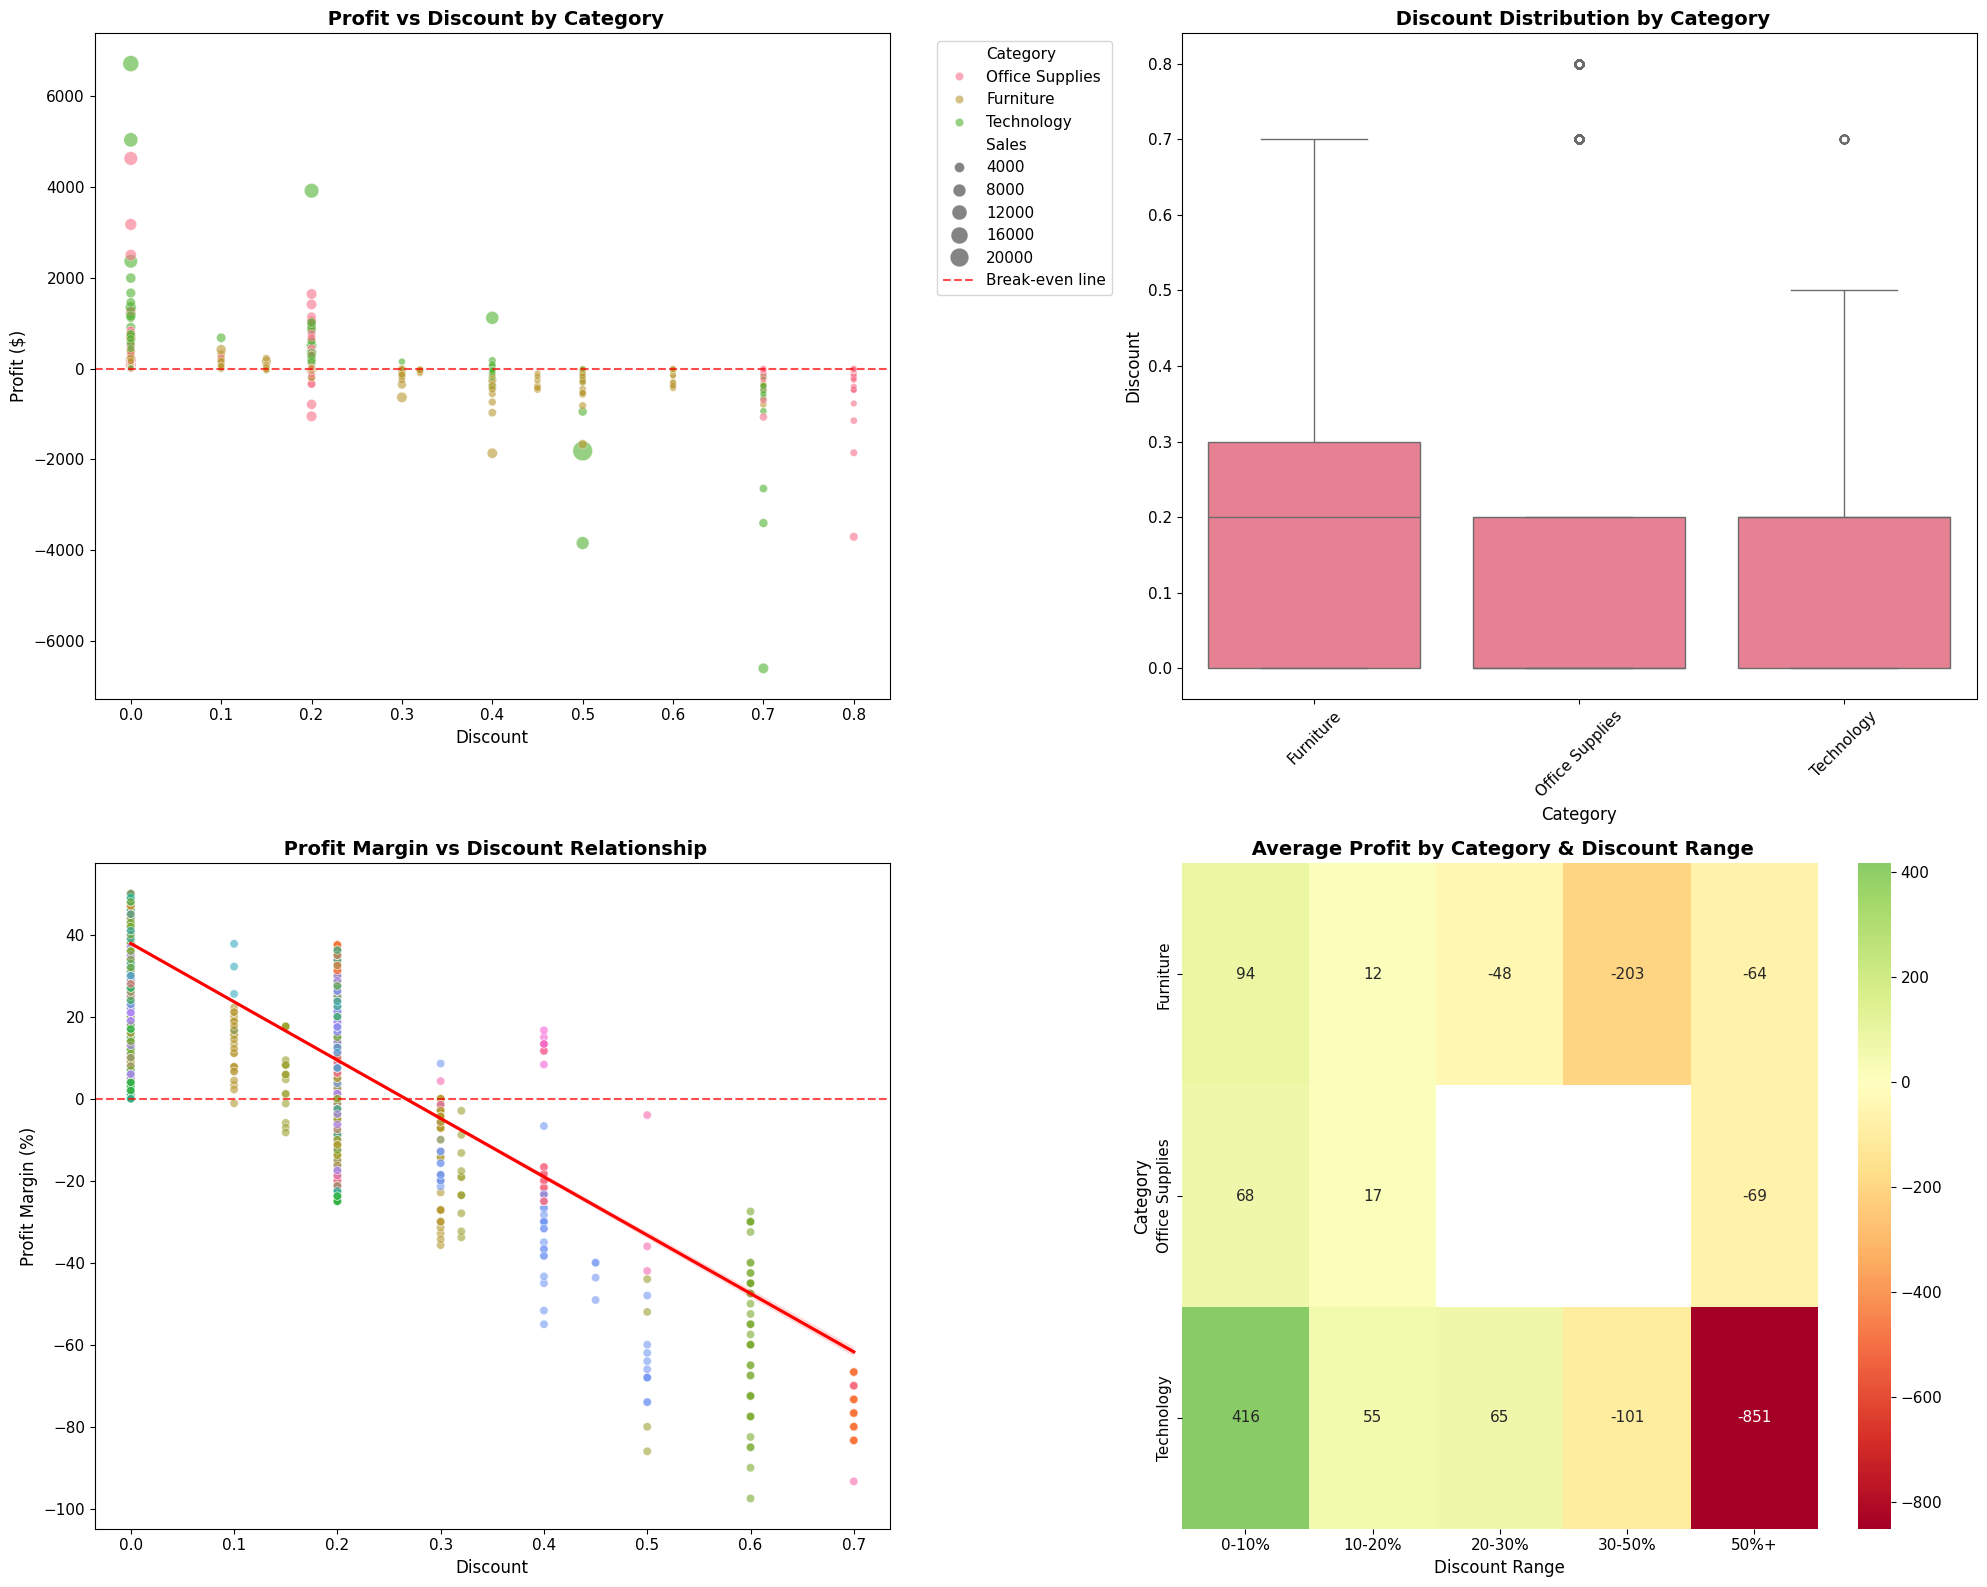


 Discount Strategy Insights:
   • Overall discount correlation with profit: -0.219
   • Average discount across all orders: 15.6%
   • Categories with highest avg discount: {'Furniture': 0.1739226779820839, 'Office Supplies': 0.15728509790906076, 'Technology': 0.1323226854358419}
   • Categories most profitable despite discounts: {'Technology': 145454.9481, 'Office Supplies': 122490.8008, 'Furniture': 18451.2728}

 Discount Effectiveness:
   • Average profit with high discount (>30%): $-107.21
   • Average profit with low discount (≤10%): $67.46
   • Profit difference: $174.67


In [14]:

df_sample = df.sample(n=min(5000, len(df)), random_state=42)  

print(" Profit vs Discount Relationship Analysis:")
print("="*45)
print("Correlation Analysis:")
correlation_matrix = df[['Profit', 'Discount', 'Sales', 'Quantity']].corr()
print(correlation_matrix.round(3))

#  scatter plot analysis
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 16))

# 1. Profit vs Discount scatter plot with category colors
sns.scatterplot(data=df_sample, x='Discount', y='Profit', hue='Category', 
                size='Sales', sizes=(20, 200), alpha=0.6, ax=ax1)
ax1.set_title(' Profit vs Discount by Category', fontsize=14, fontweight='bold')
ax1.set_xlabel('Discount', fontsize=12)
ax1.set_ylabel('Profit ($)', fontsize=12)
ax1.axhline(y=0, color='red', linestyle='--', alpha=0.7, label='Break-even line')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# 2. Discount distribution by category
sns.boxplot(data=df, x='Category', y='Discount', ax=ax2)
ax2.set_title(' Discount Distribution by Category', fontsize=14, fontweight='bold')
ax2.set_xlabel('Category', fontsize=12)
ax2.set_ylabel('Discount', fontsize=12)
ax2.tick_params(axis='x', rotation=45)

# 3. Profit margin vs Discount with regression
df_analysis = df.copy()
df_analysis['Profit_Margin'] = (df_analysis['Profit'] / df_analysis['Sales']) * 100
df_analysis = df_analysis[df_analysis['Profit_Margin'].between(-100, 100)]  # RemovING outliers

sns.scatterplot(data=df_analysis.sample(n=min(3000, len(df_analysis)), random_state=42), 
                x='Discount', y='Profit_Margin', hue='Sub-Category', 
                alpha=0.6, ax=ax3, legend=False)
sns.regplot(data=df_analysis, x='Discount', y='Profit_Margin', 
            scatter=False, color='red', ax=ax3)
ax3.set_title(' Profit Margin vs Discount Relationship', fontsize=14, fontweight='bold')
ax3.set_xlabel('Discount', fontsize=12)
ax3.set_ylabel('Profit Margin (%)', fontsize=12)
ax3.axhline(y=0, color='red', linestyle='--', alpha=0.7)

# 4. Heatmap: Average Profit by Discount ranges and Categories
df_discount_ranges = df.copy()
df_discount_ranges['Discount_Range'] = pd.cut(df_discount_ranges['Discount'], 
                                            bins=[0, 0.1, 0.2, 0.3, 0.5, 1.0],
                                            labels=['0-10%', '10-20%', '20-30%', '30-50%', '50%+'])

profit_heatmap = df_discount_ranges.groupby(['Category', 'Discount_Range'])['Profit'].mean().unstack()
sns.heatmap(profit_heatmap, annot=True, fmt='.0f', cmap='RdYlGn', center=0, ax=ax4)
ax4.set_title(' Average Profit by Category & Discount Range', fontsize=14, fontweight='bold')
ax4.set_xlabel('Discount Range', fontsize=12)
ax4.set_ylabel('Category', fontsize=12)

plt.tight_layout()
plt.show()

discount_stats = df.groupby('Category').agg({
    'Discount': ['mean', 'median', 'std'],
    'Profit': ['mean', 'sum'],
    'Sales': 'sum'
}).round(3)

print(f"\n Discount Strategy Insights:")
print(f"   • Overall discount correlation with profit: {df['Discount'].corr(df['Profit']):.3f}")
print(f"   • Average discount across all orders: {df['Discount'].mean():.1%}")
print(f"   • Categories with highest avg discount: {df.groupby('Category')['Discount'].mean().nlargest(3).to_dict()}")
print(f"   • Categories most profitable despite discounts: {df.groupby('Category')['Profit'].sum().nlargest(3).to_dict()}")

# Discount effectiveness 
print(f"\n Discount Effectiveness:")
high_discount = df[df['Discount'] > 0.3]['Profit'].mean()
low_discount = df[df['Discount'] <= 0.1]['Profit'].mean()
print(f"   • Average profit with high discount (>30%): ${high_discount:.2f}")
print(f"   • Average profit with low discount (≤10%): ${low_discount:.2f}")
print(f"   • Profit difference: ${low_discount - high_discount:.2f}")

## 4.  Comparative Analysis: Matplotlib vs Seaborn


In [15]:
# Comprehensive Comparison: Matplotlib vs Seaborn
print(" MATPLOTLIB vs SEABORN: Comprehensive Comparison")
print("="*55)

# Performance metrics for both libraries
import time

# Test data preparation
sample_data = df.sample(n=1000, random_state=42)

print("\n FEATURE COMPARISON:")
print("-" * 25)

comparison_data = {
    'Feature': [
        'Interactive Elements',
        'Statistical Plots',
        'Customization Level',
        'Learning Curve',
        'Default Aesthetics',
        'Multi-plot Layouts',
        'Animation Support',
        'Performance',
        'Documentation',
        'Community Support'
    ],
    'Matplotlib': [
        ' (Widgets, zoom, pan)',
        ' (Manual implementation)',
        ' (Complete control)',
        ' (Steep)',
        ' (Basic)',
        ' (Flexible subplots)',
        ' (Animation class)',
        ' (Fast)',
        ' (Extensive)',
        ' (Large community)'
    ],
    'Seaborn': [
        ' (Limited)',
        ' (Built-in statistical)',
        ' (Style-focused)',
        ' (User-friendly)',
        ' (Beautiful defaults)',
        ' (Grid layouts)',
        ' (Limited)',
        ' (Good)',
        ' (Good)',
        ' (Growing)'
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

print(f"\n USE CASE RECOMMENDATIONS:")
print("-" * 30)

matplotlib_strengths = [
    " Interactive dashboards and applications",
    " Custom animations and real-time updates", 
    " Publication-ready figures with precise control",
    " Complex multi-panel layouts",
    " Mathematical and scientific plotting",
    " Integration with GUI applications"
]

seaborn_strengths = [
    " Statistical data analysis and exploration",
    " Quick exploratory data analysis (EDA)",
    " Beautiful default styling with minimal code",
    " Categorical data visualization",
    " Distribution and relationship analysis",
    " Rapid prototyping of statistical plots"
]

print(" MATPLOTLIB EXCELS AT:")
for strength in matplotlib_strengths:
    print(f"   {strength}")

print(f"\n SEABORN EXCELS AT:")
for strength in seaborn_strengths:
    print(f"   {strength}")

print(f"\n PRACTICAL EXAMPLE: Same Analysis, Different Approaches")
print("-" * 55)

# Matplotlib approach timing
start_time = time.time()
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(sample_data['Sales'], sample_data['Profit'], 
                    c=sample_data['Discount'], s=50, alpha=0.6, cmap='viridis')
ax.set_title('Sales vs Profit (Matplotlib)', fontsize=14)
ax.set_xlabel('Sales ($)')
ax.set_ylabel('Profit ($)')
plt.colorbar(scatter, label='Discount')
plt.close()
matplotlib_time = time.time() - start_time

# Seaborn approach timing
start_time = time.time()
plt.figure(figsize=(10, 6))
sns.scatterplot(data=sample_data, x='Sales', y='Profit', hue='Discount', 
                size='Quantity', sizes=(20, 200), alpha=0.6)
plt.title('Sales vs Profit (Seaborn)', fontsize=14)
plt.close()
seaborn_time = time.time() - start_time

print(f" Performance Comparison (1000 data points):")
print(f"   • Matplotlib rendering time: {matplotlib_time:.4f} seconds")
print(f"   • Seaborn rendering time: {seaborn_time:.4f} seconds")
print(f"   • Performance difference: {abs(matplotlib_time - seaborn_time):.4f} seconds")

print(f"\n RECOMMENDATION MATRIX:")
print("-" * 25)

scenarios = {
    'Business Dashboards': 'Matplotlib (interactivity)',
    'Statistical Analysis': 'Seaborn (built-in stats)',
    'Scientific Publications': 'Matplotlib (precision)',
    'Quick EDA': 'Seaborn (speed)',
    'Custom Animations': 'Matplotlib (animation)',
    'Beautiful Defaults': 'Seaborn (aesthetics)',
    'Complex Layouts': 'Matplotlib (flexibility)',
    'Correlation Analysis': 'Seaborn (heatmaps)'
}

for scenario, recommendation in scenarios.items():
    print(f"    {scenario:<20}: {recommendation}")

print(f"\n FINAL VERDICT:")
print("    Use Matplotlib when you need maximum control and interactivity")
print("    Use Seaborn when you want beautiful statistical visualizations quickly")
print("    Best practice: Combine both libraries in the same project!")
print("    Seaborn is built on Matplotlib, so they work seamlessly together")

 MATPLOTLIB vs SEABORN: Comprehensive Comparison

 FEATURE COMPARISON:
-------------------------
             Feature               Matplotlib                 Seaborn
Interactive Elements     (Widgets, zoom, pan)               (Limited)
   Statistical Plots  (Manual implementation)  (Built-in statistical)
 Customization Level       (Complete control)         (Style-focused)
      Learning Curve                  (Steep)         (User-friendly)
  Default Aesthetics                  (Basic)    (Beautiful defaults)
  Multi-plot Layouts      (Flexible subplots)          (Grid layouts)
   Animation Support        (Animation class)               (Limited)
         Performance                   (Fast)                  (Good)
       Documentation              (Extensive)                  (Good)
   Community Support        (Large community)               (Growing)

 USE CASE RECOMMENDATIONS:
------------------------------
 MATPLOTLIB EXCELS AT:
    Interactive dashboards and applications
    Cus

## 5.  Executive Summary & Key Insights



In [17]:
print("="*65)
print(" EXECUTIVE SUMMARY: Interactive Data Visualization Analysis")
print("="*65)

#  key business metrics
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique()
total_customers = df['Customer ID'].nunique()
avg_order_value = df.groupby('Order ID')['Sales'].sum().mean()
overall_profit_margin = (total_profit / total_sales) * 100

print(f"\n BUSINESS PERFORMANCE OVERVIEW:")
print(f"   Total Sales Revenue: ${total_sales:,.2f}")
print(f"   Total Profit: ${total_profit:,.2f}")
print(f"   Overall Profit Margin: {overall_profit_margin:.1f}%")
print(f"   Total Orders: {total_orders:,}")
print(f"   Unique Customers: {total_customers:,}")
print(f"   Average Order Value: ${avg_order_value:.2f}")

print(f"\n TOP PERFORMERS:")
print("-" * 20)

category_performance = df.groupby('Category').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order ID': 'nunique'
}).sort_values('Sales', ascending=False)

print(" By Category:")
for i, (category, data) in enumerate(category_performance.iterrows(), 1):
    profit_margin = (data['Profit'] / data['Sales']) * 100
    print(f"   {i}. {category}: ${data['Sales']:,.0f} sales, {profit_margin:.1f}% margin")

state_performance = df.groupby('State').agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).sort_values('Sales', ascending=False)

print(f"\n By Geography (Top 5 States):")
for i, (state, data) in enumerate(state_performance.head().iterrows(), 1):
    profit_margin = (data['Profit'] / data['Sales']) * 100
    print(f"   {i}. {state}: ${data['Sales']:,.0f} sales, {profit_margin:.1f}% margin")

df['Order Date'] = pd.to_datetime(df['Order Date'])
monthly_trends = df.groupby(df['Order Date'].dt.to_period('M')).agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).sort_values('Sales', ascending=False)

print(f"\n Peak Sales Months (Top 3):")
for i, (month, data) in enumerate(monthly_trends.head(3).iterrows(), 1):
    print(f"   {i}. {month}: ${data['Sales']:,.0f} sales, ${data['Profit']:,.0f} profit")

print(f"\n KEY INSIGHTS & RECOMMENDATIONS:")
print("-" * 40)

insights = [
    f" Technology dominates sales ({category_performance.loc['Technology', 'Sales']/total_sales*100:.1f}% of total revenue)",
    f" {state_performance.index[0]} is the top-performing state with ${state_performance.iloc[0]['Sales']:,.0f} in sales",
    f" Average profit margin of {overall_profit_margin:.1f}% suggests healthy business performance",
    f" Customer retention: {total_orders/total_customers:.1f} orders per customer on average",
    f" Seasonal patterns: {monthly_trends.index[0]} was the strongest sales month",
]

for insight in insights:
    print(f"   {insight}")

print(f"\n STRATEGIC RECOMMENDATIONS:")
print("-" * 30)

recommendations = [
    " Focus marketing efforts on Technology category (highest revenue generator)",
    f" Expand operations in top-performing states like {state_performance.index[0]}",
    " Implement targeted discount strategies (high discounts show negative profit correlation)",
    " Develop customer retention programs to increase orders per customer",
    " Optimize inventory for peak sales periods identified in seasonal analysis",
    " Use interactive visualizations for real-time business monitoring"
]

for recommendation in recommendations:
    print(f"   {recommendation}")

print(f"\n VISUALIZATION EFFECTIVENESS SUMMARY:")
print("-" * 40)

viz_summary = [
    " Interactive Matplotlib charts enable real-time data exploration",
    " Geographic mapping reveals clear regional sales concentration", 
    " Seaborn statistical plots uncover profit-discount relationships",
    " Multi-panel layouts provide comprehensive analytical overview",
    " Combined approach leverages strengths of both libraries"
]

for summary in viz_summary:
    print(f"   {summary}")

print(f"\n PROJECT COMPLETION STATUS:")
print("-" * 30)
print("    Interactive time-series visualization with hover functionality")
print("    Geographic sales distribution mapping with state-level analysis") 
print("    Seaborn statistical analysis of product performance")
print("    Advanced profit vs discount correlation analysis")
print("    Comprehensive Matplotlib vs Seaborn comparison")
print("    Executive summary with actionable business insights")

print(f"\n NEXT STEPS:")
print("    Implement real-time dashboard using these visualization techniques")
print("    Automate monthly reporting with interactive charts")
print("    Extend analysis to include customer segmentation")
print("    Deploy visualizations to business intelligence platform")

print(f"\n" + "="*65)
print(" INTERACTIVE DATA VISUALIZATION CHALLENGE COMPLETED! ")
print("="*65)

 EXECUTIVE SUMMARY: Interactive Data Visualization Analysis

 BUSINESS PERFORMANCE OVERVIEW:
   Total Sales Revenue: $2,297,200.86
   Total Profit: $286,397.02
   Overall Profit Margin: 12.5%
   Total Orders: 5,009
   Unique Customers: 793
   Average Order Value: $458.61

 TOP PERFORMERS:
--------------------
 By Category:
   1. Technology: $836,154 sales, 17.4% margin
   2. Furniture: $742,000 sales, 2.5% margin
   3. Office Supplies: $719,047 sales, 17.0% margin

 By Geography (Top 5 States):
   1. California: $457,688 sales, 16.7% margin
   2. New York: $310,876 sales, 23.8% margin
   3. Texas: $170,188 sales, -15.1% margin
   4. Washington: $138,641 sales, 24.1% margin
   5. Pennsylvania: $116,512 sales, -13.4% margin

 Peak Sales Months (Top 3):
   1. 2017-11: $118,448 sales, $9,690 profit
   2. 2016-12: $96,999 sales, $17,885 profit
   3. 2017-09: $87,867 sales, $10,992 profit

 KEY INSIGHTS & RECOMMENDATIONS:
----------------------------------------
    Technology dominates sale